In [12]:
# Path bootstrap: if running from ./test_notebooks, move to project root
from pathlib import Path
import os

cwd = Path.cwd().resolve()
if cwd.name == "test_notebooks":
    os.chdir(cwd.parent)
    cwd = Path.cwd().resolve()
elif cwd.name == "bhchen":
    target = cwd / "Learn_DA_selfuse"
    if target.exists():
        os.chdir(target)
        cwd = Path.cwd().resolve()

print("Current working directory:", cwd)



Current working directory: /resnick/groups/astuart/bhchen/Learn_DA_selfuse


In [13]:
import math
import os
import re
from dataclasses import dataclass, field
from pathlib import Path
from typing import Sequence

from config.dataset_info import DATASET_INFO

import matplotlib.pyplot as plt
import torch


def locate_project_root(start: Path | None = None) -> Path:
    cursor = (start or Path.cwd()).resolve()
    for candidate in [cursor, *cursor.parents]:
        if (candidate / "data").exists() and (candidate / "test_notebooks").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root that contains both data/ and test_notebooks/.")


PROJECT_ROOT = locate_project_root()
os.chdir(PROJECT_ROOT)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
eps = 1e-12
_AUTO_TOKENS = {"auto", "adaptive", "any", "*"}
_LEN_PATTERN = re.compile(r"_len_(\d+)_pfN_")
_PF_RESULT_PATTERN = re.compile(
    r"^pf_results_sigma_y_(?P<sigma>[^_]+)_batch_(?P<batch>\d+)_len_(?P<seq_len>\d+)_pfN_(?P<pf_N>\d+)_(?P<seed>\d+)(?P<obs_suffix>_[^.]+)?\.pt$"
)

# Train/test utils alignment: only keep rmse/cov_diff (+ relative) families.
PF_METRIC_ALIASES = {
    "mean_pf_rmse": ["mean_pf_rmse", "mean_rmse", "pf_rmse", "rmse"],
    "std_pf_rmse": ["std_pf_rmse", "std_rmse"],
    "mean_pf_rrmse": ["mean_pf_rrmse", "mean_rrmse", "pf_rrmse", "rrmse"],
    "std_pf_rrmse": ["std_pf_rrmse", "std_rrmse"],
    "mean_pf_cov_diff": ["mean_pf_cov_diff", "mean_cov_diff", "pf_cov_diff", "cov_diff"],
    "std_pf_cov_diff": ["std_pf_cov_diff", "std_cov_diff"],
    "mean_pf_rcov_diff": ["mean_pf_rcov_diff", "mean_rcov_diff", "pf_rcov_diff", "rcov_diff"],
    "std_pf_rcov_diff": ["std_pf_rcov_diff", "std_rcov_diff"],
}

print(f"Project root: {PROJECT_ROOT}")
print(f"Device: {device}")


@dataclass
class ExperimentConfig:
    name: str
    dataset: str
    sigma_y: float | str | None
    input_len: int
    output_len: int | None = None
    obs_fn: str = "default"
    data_subdir: str | None = None
    batch_size: int = 64
    dt: float = 0.15
    pf_N_list: Sequence[int] = field(default_factory=list)
    seed_list: Sequence[int] = field(default_factory=list)
    max_t_list: Sequence[int] = field(default_factory=list)
    len_candidates: Sequence[int] = field(default_factory=list)
    save_avg: bool = False  # disabled: notebook is plotting-only
    verbose: bool = True

    def __post_init__(self) -> None:
        if self.output_len is None:
            self.output_len = self.input_len

    @property
    def data_dir(self) -> Path:
        return PROJECT_ROOT / "data" / self.dataset


def _is_auto_token(value: object) -> bool:
    return str(value or "").strip().lower() in _AUTO_TOKENS


def _normalize_obs_fn(obs_fn: object) -> str:
    token = str(obs_fn or "").strip().lower()
    if token.startswith("fn_"):
        token = token[3:]
    return token


def _sigma_aliases(sigma_y: float | str | None) -> list[str]:
    if sigma_y is None or _is_auto_token(sigma_y):
        return []

    raw = str(sigma_y).strip()
    aliases = {raw}
    try:
        sigma_float = float(raw)
        aliases.add(f"{sigma_float:.1f}")
        aliases.add(f"{sigma_float:.2f}")
        if sigma_float.is_integer():
            aliases.add(str(int(sigma_float)))
    except (TypeError, ValueError):
        pass
    return sorted(aliases)


def _default_sigma_str(sigma_y: float | str | None) -> str:
    if sigma_y is None or _is_auto_token(sigma_y):
        return "auto"
    try:
        return f"{float(sigma_y):.1f}"
    except (TypeError, ValueError):
        return str(sigma_y)


def _parse_len(path: Path) -> int | None:
    matched = _LEN_PATTERN.search(path.name)
    return int(matched.group(1)) if matched else None


def _default_obs_fn(dataset: str) -> str:
    cfg = DATASET_INFO.get(str(dataset).lower(), {})
    return _normalize_obs_fn(cfg.get("obs_fn", "identity") or "identity")


def _obs_suffix(cfg: ExperimentConfig) -> str | None:
    default_obs_fn = _default_obs_fn(cfg.dataset)
    obs_fn = _normalize_obs_fn(cfg.obs_fn or "default")
    if _is_auto_token(obs_fn):
        return None
    if obs_fn == "default":
        obs_fn = default_obs_fn
    return "" if obs_fn == default_obs_fn else f"_{obs_fn}"


def _build_file_name(sigma_str: str, batch_size: int, seq_len: int, pf_N: int, seed: int, obs_suffix: str = "") -> str:
    return f"pf_results_sigma_y_{sigma_str}_batch_{batch_size}_len_{seq_len}_pfN_{pf_N}_{seed}{obs_suffix}.pt"


def _parse_pf_result_file(path: Path) -> dict[str, object] | None:
    matched = _PF_RESULT_PATTERN.match(path.name)
    if matched is None:
        return None
    return {
        "sigma_str": matched.group("sigma"),
        "batch": int(matched.group("batch")),
        "seq_len": int(matched.group("seq_len")),
        "pf_N": int(matched.group("pf_N")),
        "seed": int(matched.group("seed")),
        "obs_suffix": matched.group("obs_suffix") or "",
    }


def _candidate_data_dirs(cfg: ExperimentConfig) -> list[Path]:
    root = cfg.data_dir
    out: list[Path] = []

    if cfg.data_subdir:
        out.append(root / cfg.data_subdir)

    obs_suffix = _obs_suffix(cfg)
    obs_token = ""
    if obs_suffix:
        obs_token = obs_suffix.lstrip("_")

    if obs_token:
        out.append(root / f"fn_{obs_token}")
        out.append(root / f"pf_{obs_token}")

    out.append(root)

    dedup: list[Path] = []
    seen: set[str] = set()
    for p in out:
        key = str(p.resolve()) if p.exists() else str(p)
        if key in seen:
            continue
        seen.add(key)
        dedup.append(p)
    return dedup


def resolve_seed_file(cfg: ExperimentConfig, pf_N: int, seed: int) -> tuple[Path | None, bool]:
    obs_suffix = _obs_suffix(cfg)
    sigma_opts = _sigma_aliases(cfg.sigma_y)
    len_opts = [cfg.input_len, *cfg.len_candidates]
    len_set = set(len_opts)

    pattern = f"pf_results_sigma_y_*_batch_{cfg.batch_size}_len_*_pfN_{pf_N}_*.pt"
    parsed_matches: list[tuple[Path, dict[str, object]]] = []
    for data_dir in _candidate_data_dirs(cfg):
        if not data_dir.exists():
            continue
        for candidate in data_dir.glob(pattern):
            meta = _parse_pf_result_file(candidate)
            if meta is None:
                continue
            if meta["seed"] != seed:
                continue
            parsed_matches.append((candidate, meta))

    if not parsed_matches:
        return None, False

    # obs_fn matching: explicit obs_fn is strict; auto mode allows unique suffix only.
    if obs_suffix is not None:
        obs_matches = [item for item in parsed_matches if item[1]["obs_suffix"] == obs_suffix]
        if not obs_matches:
            return None, False
    else:
        obs_values = {item[1]["obs_suffix"] for item in parsed_matches}
        if len(obs_values) > 1:
            if cfg.verbose:
                print(
                    f"pf_N={pf_N}, seed={seed}: multiple obs suffix {sorted(obs_values)} in auto mode; set obs_fn explicitly."
                )
            return None, False
        obs_matches = parsed_matches

    # sigma_y matching: explicit sigma first; if not found, fallback to unique sigma only.
    sigma_matches = obs_matches
    if sigma_opts:
        explicit_sigma = [item for item in obs_matches if item[1]["sigma_str"] in sigma_opts]
        if explicit_sigma:
            sigma_matches = explicit_sigma
        else:
            sigma_values = {item[1]["sigma_str"] for item in obs_matches}
            if len(sigma_values) != 1:
                if cfg.verbose:
                    print(
                        f"pf_N={pf_N}, seed={seed}: ambiguous sigma_y {sorted(sigma_values)}, set sigma_y explicitly."
                    )
                return None, False
            if cfg.verbose:
                wanted_sigma = cfg.sigma_y
                auto_sigma = next(iter(sigma_values))
                print(
                    f"pf_N={pf_N}, seed={seed}: sigma_y={wanted_sigma} not found; auto-used {auto_sigma}."
                )
    else:
        sigma_values = {item[1]["sigma_str"] for item in obs_matches}
        if len(sigma_values) > 1:
            if cfg.verbose:
                print(
                    f"pf_N={pf_N}, seed={seed}: multiple sigma_y {sorted(sigma_values)} in auto mode; set sigma_y explicitly."
                )
            return None, False

    # Prefer configured lengths; then nearest available length.
    strict_len = [item for item in sigma_matches if item[1]["seq_len"] in len_set]
    ranked_source = strict_len or sigma_matches
    ranked = sorted(
        ranked_source,
        key=lambda item: (
            0 if item[1]["seq_len"] == cfg.input_len else 1,
            abs(item[1]["seq_len"] - cfg.input_len),
            0 if item[1]["seq_len"] in len_set else 1,
            item[0].name,
        ),
    )

    best_path, best_meta = ranked[0]
    used_len_fallback = best_meta["seq_len"] != cfg.input_len
    return best_path, used_len_fallback


def _scalar_or_none(value: object) -> float | None:
    if value is None:
        return None
    if isinstance(value, torch.Tensor):
        if value.numel() != 1:
            return None
        value = value.item()
    try:
        return float(value)
    except (TypeError, ValueError):
        return None


def _all_same_shape(tensors: Sequence[torch.Tensor]) -> bool:
    if len(tensors) <= 1:
        return True
    ref = tuple(tensors[0].shape)
    return all(tuple(t.shape) == ref for t in tensors[1:])


def _extract_pf_metrics(entry: dict[str, object]) -> dict[str, float]:
    out: dict[str, float] = {}
    for canonical_key, aliases in PF_METRIC_ALIASES.items():
        value = None
        for key in aliases:
            if key in entry:
                value = _scalar_or_none(entry.get(key))
                if value is not None:
                    break
        out[canonical_key] = float("nan") if value is None else value
    return out


def _pick_key_from_entries(entries: list[dict[str, object]], candidates: Sequence[str]) -> str | None:
    for key in candidates:
        for entry in entries:
            if key in entry:
                return key
    return None


def _concat_from_entries(entries: list[dict[str, object]], key: str) -> torch.Tensor | None:
    tensors: list[torch.Tensor] = []
    for entry in entries:
        value = entry.get(key)
        if not isinstance(value, torch.Tensor):
            return None
        tensors.append(value.to(torch.float32))

    if not tensors:
        return None

    if tensors[0].ndim >= 2:
        ref_t = tensors[0].shape[0]
        ref_tail = tensors[0].shape[2:]
        for t in tensors[1:]:
            if t.shape[0] != ref_t or tuple(t.shape[2:]) != tuple(ref_tail):
                return None
        return torch.cat(tensors, dim=1)

    return torch.cat(tensors, dim=0)


def _get_quantile_probs_from_entries(entries: list[dict[str, object]]) -> torch.Tensor | None:
    for entry in entries:
        q = entry.get("quantile_probs")
        if isinstance(q, torch.Tensor):
            return q.to(torch.float32)
    return None


def _build_quantile_6d_from_entries(entries: list[dict[str, object]]) -> torch.Tensor | None:
    state_key = _pick_key_from_entries(entries, ["post_quantiles", "quantiles"])
    pca_key = _pick_key_from_entries(entries, ["post_pca_quantiles", "pca_quantiles"])

    q_state = _concat_from_entries(entries, state_key) if state_key is not None else None
    q_pca = _concat_from_entries(entries, pca_key) if pca_key is not None else None
    if q_state is None and q_pca is None:
        return None

    if q_state is not None:
        t_dim, b_dim, _, k_dim = q_state.shape
        dev = q_state.device
    else:
        t_dim, b_dim, _, k_dim = q_pca.shape
        dev = q_pca.device

    out = torch.full((t_dim, b_dim, 6, k_dim), float("nan"), device=dev, dtype=torch.float32)
    if q_state is not None:
        d = min(3, q_state.shape[2])
        out[:, :, :d, :] = q_state[:, :, :d, :]
    if q_pca is not None:
        d = min(3, q_pca.shape[2])
        out[:, :, 3:3 + d, :] = q_pca[:, :, :d, :]
    return out


def load_pf_payload(file_path: Path, map_to_device: torch.device) -> tuple[torch.Tensor, torch.Tensor, dict[str, float], dict[str, torch.Tensor | None]]:
    data = torch.load(file_path, weights_only=True, map_location=map_to_device)
    if isinstance(data, list):
        entries = [entry for entry in data if isinstance(entry, dict)]
    elif isinstance(data, dict):
        entries = [data]
    else:
        raise TypeError(f"Unsupported PF payload type in {file_path.name}: {type(data)}")

    if not entries:
        raise TypeError(f"No dict entries found in {file_path.name}")

    mean_key = _pick_key_from_entries(entries, ["means", "post_means"])
    cov_key = _pick_key_from_entries(entries, ["covs", "post_covs"])
    if mean_key is None or cov_key is None:
        raise KeyError(f"Missing mean/cov keys in {file_path.name}")

    mean = _concat_from_entries(entries, mean_key)
    cov = _concat_from_entries(entries, cov_key)
    if mean is None or cov is None:
        raise KeyError(f"Could not concat mean/cov tensors in {file_path.name}")

    saved_metrics = _extract_pf_metrics(entries[0])
    analysis_payload: dict[str, torch.Tensor | None] = {
        "quantiles_6d": _build_quantile_6d_from_entries(entries),
        "quantile_probs": _get_quantile_probs_from_entries(entries),
        "ess": _concat_from_entries(entries, _pick_key_from_entries(entries, ["post_ess", "ess"]) or ""),
        "weight_entropy": _concat_from_entries(entries, _pick_key_from_entries(entries, ["post_weight_entropy", "weight_entropy"]) or ""),
        "weight_abundance": _concat_from_entries(entries, _pick_key_from_entries(entries, ["post_weight_abundance", "weight_abundance"]) or ""),
        "skewness": _concat_from_entries(entries, _pick_key_from_entries(entries, ["post_skewness", "skewness"]) or ""),
        "kurtosis_excess": _concat_from_entries(entries, _pick_key_from_entries(entries, ["post_kurtosis_excess", "kurtosis_excess"]) or ""),
    }
    return mean, cov, saved_metrics, analysis_payload





Project root: /resnick/groups/astuart/bhchen/Learn_DA_selfuse
Device: cuda


In [14]:
def _se_from_seed_stack(seed_stack: torch.Tensor | None) -> torch.Tensor | None:
    if seed_stack is None or seed_stack.ndim == 0:
        return None
    k = int(seed_stack.shape[0])
    if k < 2:
        return None
    return torch.std(seed_stack, dim=0, unbiased=True) / math.sqrt(k)


def _stack_seed_tensors(values: list[torch.Tensor]) -> torch.Tensor | None:
    if len(values) < 2:
        return None
    if not _all_same_shape(values):
        return None
    return torch.stack([v.to(torch.float32) for v in values], dim=0)


def _scalar_mean_min_max(values: list[float]) -> tuple[float, float, float]:
    finite = [float(v) for v in values if math.isfinite(float(v))]
    if not finite:
        return float("nan"), float("nan"), float("nan")
    x = torch.tensor(finite, dtype=torch.float32)
    return float(torch.mean(x).item()), float(torch.min(x).item()), float(torch.max(x).item())


def _tensor_mean_min_max(values: list[torch.Tensor]) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor] | None:
    if not values or not _all_same_shape(values):
        return None
    x = torch.stack([v.to(torch.float32) for v in values], dim=0)
    return torch.mean(x, dim=0), torch.min(x, dim=0).values, torch.max(x, dim=0).values


def _tensor_range(values: list[torch.Tensor]) -> torch.Tensor | None:
    if not values or not _all_same_shape(values):
        return None
    x = torch.stack([v.to(torch.float32) for v in values], dim=0)
    return torch.max(x, dim=0).values - torch.min(x, dim=0).values


def _compute_extra_seed_analysis(
    mean_tensor: torch.Tensor,
    cov_tensor: torch.Tensor,
    seed_aux: dict[str, list[torch.Tensor]],
    quantile_probs: torch.Tensor | None,
) -> dict[str, object]:
    se_mean = _se_from_seed_stack(mean_tensor)
    se_cov = _se_from_seed_stack(cov_tensor)

    if se_mean is None:
        se_mean_rmse = float("nan")
        se_mean_avg = float("nan")
    else:
        se_mean_rmse = float(torch.nanmean(torch.sqrt(torch.mean(se_mean ** 2, dim=-1))).item())
        se_mean_avg = float(torch.nanmean(se_mean).item())

    if se_cov is None:
        se_cov_fnorm = float("nan")
        se_cov_avg = float("nan")
    else:
        se_cov_fnorm = float(torch.nanmean(torch.linalg.norm(se_cov, ord="fro", dim=(-2, -1))).item())
        se_cov_avg = float(torch.nanmean(se_cov).item())

    def _se_scalar_rmse(key: str) -> float:
        stack = _stack_seed_tensors(seed_aux.get(key, []))
        se_val = _se_from_seed_stack(stack)
        if se_val is None:
            return float("nan")
        return float(torch.sqrt(torch.nanmean(se_val ** 2)).item())

    se_ess_rmse = _se_scalar_rmse("ess")
    se_weight_entropy_rmse = _se_scalar_rmse("weight_entropy")
    se_weight_abundance_rmse = _se_scalar_rmse("weight_abundance")

    q_list = seed_aux.get("quantiles_6d", [])
    q_stack = _stack_seed_tensors(q_list)
    se_quantile_l2_dim: list[float] | None = None
    se_quantile_l2 = float("nan")
    se_quantile_avg = float("nan")
    if q_stack is not None and quantile_probs is not None and quantile_probs.ndim == 1 and q_stack.shape[-1] == quantile_probs.shape[0]:
        se_q = _se_from_seed_stack(q_stack)
        if se_q is not None:
            l2_tb_dim = torch.sqrt(torch.trapz(se_q ** 2, x=quantile_probs.to(se_q.device), dim=-1))
            l2_by_dim = torch.nanmean(l2_tb_dim, dim=(0, 1))
            se_quantile_l2_dim = [float(v) for v in l2_by_dim.tolist()]
            se_quantile_l2 = float(torch.nanmean(l2_by_dim).item())
            se_quantile_avg = float(torch.nanmean(se_q).item())

    def _se_dim_rmse(key: str) -> list[float] | None:
        stack = _stack_seed_tensors(seed_aux.get(key, []))
        se_val = _se_from_seed_stack(stack)
        if se_val is None or se_val.ndim != 3:
            return None
        return [float(v) for v in torch.sqrt(torch.nanmean(se_val ** 2, dim=(0, 1))).tolist()]

    se_skew_rmse_dim = _se_dim_rmse("skewness")
    se_kurtosis_rmse_dim = _se_dim_rmse("kurtosis_excess")

    def _seed_means_scalar(key: str) -> list[float]:
        return [float(torch.nanmean(x).item()) for x in seed_aux.get(key, [])]

    ess_seed_means = _seed_means_scalar("ess")
    entropy_seed_means = _seed_means_scalar("weight_entropy")
    abundance_seed_means = _seed_means_scalar("weight_abundance")

    ess_mean, ess_min, ess_max = _scalar_mean_min_max(ess_seed_means)
    ent_mean, ent_min, ent_max = _scalar_mean_min_max(entropy_seed_means)
    abd_mean, abd_min, abd_max = _scalar_mean_min_max(abundance_seed_means)

    def _seed_means_dim(key: str) -> list[torch.Tensor]:
        out: list[torch.Tensor] = []
        for x in seed_aux.get(key, []):
            if x.ndim == 3:
                out.append(torch.nanmean(x, dim=(0, 1)))
        return out

    skew_seed_means = _seed_means_dim("skewness")
    kurt_seed_means = _seed_means_dim("kurtosis_excess")

    skew_range = _tensor_range(skew_seed_means)
    kurt_range = _tensor_range(kurt_seed_means)
    skew_minmax = _tensor_mean_min_max(skew_seed_means)
    kurt_minmax = _tensor_mean_min_max(kurt_seed_means)

    return {
        "se_mean_rmse": se_mean_rmse,
        "se_mean_avg": se_mean_avg,
        "se_cov_fnorm": se_cov_fnorm,
        "se_cov_avg": se_cov_avg,
        "se_quantile_l2": se_quantile_l2,
        "se_quantile_avg": se_quantile_avg,
        "se_ess_rmse": se_ess_rmse,
        "se_weight_entropy_rmse": se_weight_entropy_rmse,
        "se_weight_abundance_rmse": se_weight_abundance_rmse,
        "se_quantile_l2_dim": se_quantile_l2_dim,
        "se_skew_rmse_dim": se_skew_rmse_dim,
        "se_kurtosis_rmse_dim": se_kurtosis_rmse_dim,
        "range_ess_mean": float("nan") if not ess_seed_means else float(max(ess_seed_means) - min(ess_seed_means)),
        "range_weight_entropy_mean": float("nan") if not entropy_seed_means else float(max(entropy_seed_means) - min(entropy_seed_means)),
        "range_weight_abundance_mean": float("nan") if not abundance_seed_means else float(max(abundance_seed_means) - min(abundance_seed_means)),
        "mean_ess_mean": ess_mean,
        "min_ess_mean": ess_min,
        "max_ess_mean": ess_max,
        "mean_weight_entropy_mean": ent_mean,
        "min_weight_entropy_mean": ent_min,
        "max_weight_entropy_mean": ent_max,
        "mean_weight_abundance_mean": abd_mean,
        "min_weight_abundance_mean": abd_min,
        "max_weight_abundance_mean": abd_max,
        "range_skew_mean_dim": None if skew_range is None else [float(v) for v in skew_range.tolist()],
        "mean_skew_mean_dim": None if skew_minmax is None else [float(v) for v in skew_minmax[0].tolist()],
        "min_skew_mean_dim": None if skew_minmax is None else [float(v) for v in skew_minmax[1].tolist()],
        "max_skew_mean_dim": None if skew_minmax is None else [float(v) for v in skew_minmax[2].tolist()],
        "range_kurtosis_mean_dim": None if kurt_range is None else [float(v) for v in kurt_range.tolist()],
        "mean_kurtosis_mean_dim": None if kurt_minmax is None else [float(v) for v in kurt_minmax[0].tolist()],
        "min_kurtosis_mean_dim": None if kurt_minmax is None else [float(v) for v in kurt_minmax[1].tolist()],
        "max_kurtosis_mean_dim": None if kurt_minmax is None else [float(v) for v in kurt_minmax[2].tolist()],
    }


def _maybe_float(v: object) -> float | None:
    if v is None:
        return None
    try:
        fv = float(v)
    except Exception:
        return None
    if not math.isfinite(fv):
        return None
    return fv


def _set_adaptive_y_scale(ax: object, series_list: Sequence[Sequence[float]]) -> None:
    finite_vals: list[float] = []
    for series in series_list:
        for v in series:
            try:
                fv = float(v)
            except Exception:
                continue
            if math.isfinite(fv):
                finite_vals.append(fv)

    if len(finite_vals) == 0:
        ax.set_yscale("linear")
        return
    if any(v <= 0.0 for v in finite_vals):
        ax.set_yscale("linear")
        return

    v_min = min(finite_vals)
    v_max = max(finite_vals)
    if v_min <= 0.0:
        ax.set_yscale("linear")
        return
    ax.set_yscale("log" if (v_max / v_min) >= 10.0 else "linear")


def _plot_multi_line(
    x: list[int],
    series: dict[str, list[float]],
    ylabel: str,
    title: str = "",
) -> None:
    fig, ax = plt.subplots(figsize=(12, 7))
    all_series: list[list[float]] = []
    for name, y in series.items():
        ax.plot(x, y, marker="o", label=name, linewidth=3.0, markersize=9)
        all_series.append(y)
    ax.set_xscale("log")
    _set_adaptive_y_scale(ax, all_series)
    ax.set_xlabel("N (number of particles)")
    ax.set_ylabel(ylabel)
    ax.grid(True, which="both", linestyle="--", alpha=0.5)
    ax.legend(fontsize=10, frameon=True)
    if title:
        ax.set_title(title)
    fig.tight_layout()
    plt.show()


def _plot_multi_line_with_band(
    x: list[int],
    centers: dict[str, list[float]],
    lowers: dict[str, list[float]],
    uppers: dict[str, list[float]],
    ylabel: str,
    title: str = "",
) -> None:
    fig, ax = plt.subplots(figsize=(12, 7))
    all_series: list[list[float]] = []
    for name, y in centers.items():
        y_low = lowers[name]
        y_high = uppers[name]
        ax.plot(x, y, marker="o", label=name, linewidth=3.0, markersize=9)
        ax.fill_between(x, y_low, y_high, alpha=0.2)
        all_series.extend([y, y_low, y_high])
    ax.set_xscale("log")
    _set_adaptive_y_scale(ax, all_series)
    ax.set_xlabel("N (number of particles)")
    ax.set_ylabel(ylabel)
    ax.grid(True, which="both", linestyle="--", alpha=0.5)
    ax.legend(fontsize=10, frameon=True)
    if title:
        ax.set_title(title)
    fig.tight_layout()
    plt.show()


def _plot_analyze_pf_results_style(
    cfg: ExperimentConfig,
    analysis_metrics_by_pf: dict[int, dict[str, object]],
    pf_N_axis: Sequence[int],
) -> None:
    if not pf_N_axis:
        return
    available_n = list(pf_N_axis)

    _plot_multi_line(
        x=available_n,
        series={
            "mean RMSE SE": [float("nan") if _maybe_float(analysis_metrics_by_pf[n].get("se_mean_rmse")) is None else float(analysis_metrics_by_pf[n]["se_mean_rmse"]) for n in available_n],
            "mean avg SE": [float("nan") if _maybe_float(analysis_metrics_by_pf[n].get("se_mean_avg")) is None else float(analysis_metrics_by_pf[n]["se_mean_avg"]) for n in available_n],
            "cov F-norm SE": [float("nan") if _maybe_float(analysis_metrics_by_pf[n].get("se_cov_fnorm")) is None else float(analysis_metrics_by_pf[n]["se_cov_fnorm"]) for n in available_n],
            "cov avg SE": [float("nan") if _maybe_float(analysis_metrics_by_pf[n].get("se_cov_avg")) is None else float(analysis_metrics_by_pf[n]["se_cov_avg"]) for n in available_n],
            "quantile L2[0,1] SE": [float("nan") if _maybe_float(analysis_metrics_by_pf[n].get("se_quantile_l2")) is None else float(analysis_metrics_by_pf[n]["se_quantile_l2"]) for n in available_n],
            "quantile avg SE": [float("nan") if _maybe_float(analysis_metrics_by_pf[n].get("se_quantile_avg")) is None else float(analysis_metrics_by_pf[n]["se_quantile_avg"]) for n in available_n],
        },
        ylabel="Standard Error",
        title=f"{cfg.name} | mean/cov/quantile SE",
    )

    state_quantile_series: dict[str, list[float]] = {}
    pca_quantile_series: dict[str, list[float]] = {}
    for q_dim, q_name in enumerate(["x1", "x2", "x3", "pca1", "pca2", "pca3"]):
        y: list[float] = []
        for n in available_n:
            arr = analysis_metrics_by_pf[n].get("se_quantile_l2_dim")
            if isinstance(arr, list) and q_dim < len(arr):
                y.append(float(arr[q_dim]))
            else:
                y.append(float("nan"))
        if q_dim < 3:
            state_quantile_series[f"{q_name} quantile SE"] = y
        else:
            pca_quantile_series[f"{q_name} quantile SE"] = y

    _plot_multi_line(
        x=available_n,
        series=state_quantile_series,
        ylabel="Quantile L2 SE",
        title=f"{cfg.name} | state quantile SE",
    )
    _plot_multi_line(
        x=available_n,
        series=pca_quantile_series,
        ylabel="Quantile L2 SE",
        title=f"{cfg.name} | PCA quantile SE",
    )

    _plot_multi_line_with_band(
        x=available_n,
        centers={
            "ESS mean": [float("nan") if _maybe_float(analysis_metrics_by_pf[n].get("mean_ess_mean")) is None else float(analysis_metrics_by_pf[n]["mean_ess_mean"]) for n in available_n],
        },
        lowers={
            "ESS mean": [float("nan") if _maybe_float(analysis_metrics_by_pf[n].get("min_ess_mean")) is None else float(analysis_metrics_by_pf[n]["min_ess_mean"]) for n in available_n],
        },
        uppers={
            "ESS mean": [float("nan") if _maybe_float(analysis_metrics_by_pf[n].get("max_ess_mean")) is None else float(analysis_metrics_by_pf[n]["max_ess_mean"]) for n in available_n],
        },
        ylabel="ESS mean",
        title=f"{cfg.name} | ESS mean with seed range",
    )

    _plot_multi_line_with_band(
        x=available_n,
        centers={
            "weight entropy mean": [float("nan") if _maybe_float(analysis_metrics_by_pf[n].get("mean_weight_entropy_mean")) is None else float(analysis_metrics_by_pf[n]["mean_weight_entropy_mean"]) for n in available_n],
        },
        lowers={
            "weight entropy mean": [float("nan") if _maybe_float(analysis_metrics_by_pf[n].get("min_weight_entropy_mean")) is None else float(analysis_metrics_by_pf[n]["min_weight_entropy_mean"]) for n in available_n],
        },
        uppers={
            "weight entropy mean": [float("nan") if _maybe_float(analysis_metrics_by_pf[n].get("max_weight_entropy_mean")) is None else float(analysis_metrics_by_pf[n]["max_weight_entropy_mean"]) for n in available_n],
        },
        ylabel="Weight entropy mean",
        title=f"{cfg.name} | entropy mean with seed range",
    )

    _plot_multi_line_with_band(
        x=available_n,
        centers={
            "weight abundance mean": [float("nan") if _maybe_float(analysis_metrics_by_pf[n].get("mean_weight_abundance_mean")) is None else float(analysis_metrics_by_pf[n]["mean_weight_abundance_mean"]) for n in available_n],
        },
        lowers={
            "weight abundance mean": [float("nan") if _maybe_float(analysis_metrics_by_pf[n].get("min_weight_abundance_mean")) is None else float(analysis_metrics_by_pf[n]["min_weight_abundance_mean"]) for n in available_n],
        },
        uppers={
            "weight abundance mean": [float("nan") if _maybe_float(analysis_metrics_by_pf[n].get("max_weight_abundance_mean")) is None else float(analysis_metrics_by_pf[n]["max_weight_abundance_mean"]) for n in available_n],
        },
        ylabel="Weight abundance mean",
        title=f"{cfg.name} | abundance mean with seed range",
    )

    skew_dim_len = 0
    for n in available_n:
        arr = analysis_metrics_by_pf[n].get("mean_skew_mean_dim")
        if isinstance(arr, list):
            skew_dim_len = max(skew_dim_len, len(arr))
    if skew_dim_len > 0:
        skew_mean_series: dict[str, list[float]] = {}
        skew_min_series: dict[str, list[float]] = {}
        skew_max_series: dict[str, list[float]] = {}
        for d in range(skew_dim_len):
            y_mean: list[float] = []
            y_min: list[float] = []
            y_max: list[float] = []
            for n in available_n:
                mean_arr = analysis_metrics_by_pf[n].get("mean_skew_mean_dim")
                min_arr = analysis_metrics_by_pf[n].get("min_skew_mean_dim")
                max_arr = analysis_metrics_by_pf[n].get("max_skew_mean_dim")
                y_mean.append(float(mean_arr[d]) if isinstance(mean_arr, list) and d < len(mean_arr) else float("nan"))
                y_min.append(float(min_arr[d]) if isinstance(min_arr, list) and d < len(min_arr) else float("nan"))
                y_max.append(float(max_arr[d]) if isinstance(max_arr, list) and d < len(max_arr) else float("nan"))
            key = f"skew dim {d + 1} mean"
            skew_mean_series[key] = y_mean
            skew_min_series[key] = y_min
            skew_max_series[key] = y_max

        _plot_multi_line_with_band(
            x=available_n,
            centers=skew_mean_series,
            lowers=skew_min_series,
            uppers=skew_max_series,
            ylabel="Value",
            title=f"{cfg.name} | skewness mean with seed range",
        )

    kurt_dim_len = 0
    for n in available_n:
        arr = analysis_metrics_by_pf[n].get("mean_kurtosis_mean_dim")
        if isinstance(arr, list):
            kurt_dim_len = max(kurt_dim_len, len(arr))
    if kurt_dim_len > 0:
        kurt_mean_series: dict[str, list[float]] = {}
        kurt_min_series: dict[str, list[float]] = {}
        kurt_max_series: dict[str, list[float]] = {}
        for d in range(kurt_dim_len):
            y_mean: list[float] = []
            y_min: list[float] = []
            y_max: list[float] = []
            for n in available_n:
                mean_arr = analysis_metrics_by_pf[n].get("mean_kurtosis_mean_dim")
                min_arr = analysis_metrics_by_pf[n].get("min_kurtosis_mean_dim")
                max_arr = analysis_metrics_by_pf[n].get("max_kurtosis_mean_dim")
                y_mean.append(float(mean_arr[d]) if isinstance(mean_arr, list) and d < len(mean_arr) else float("nan"))
                y_min.append(float(min_arr[d]) if isinstance(min_arr, list) and d < len(min_arr) else float("nan"))
                y_max.append(float(max_arr[d]) if isinstance(max_arr, list) and d < len(max_arr) else float("nan"))
            key = f"kurt dim {d + 1} mean"
            kurt_mean_series[key] = y_mean
            kurt_min_series[key] = y_min
            kurt_max_series[key] = y_max

        _plot_multi_line_with_band(
            x=available_n,
            centers=kurt_mean_series,
            lowers=kurt_min_series,
            uppers=kurt_max_series,
            ylabel="Value",
            title=f"{cfg.name} | kurtosis mean with seed range",
        )


def _aggregate_saved_metric_stats(values: list[float]) -> tuple[float, float]:
    if not values:
        return float("nan"), float("nan")
    tensor = torch.tensor(values, dtype=torch.float32)
    valid = tensor[torch.isfinite(tensor)]
    if valid.numel() == 0:
        return float("nan"), float("nan")
    mean = float(valid.mean().item())
    std = float(valid.std(unbiased=False).item()) if valid.numel() > 1 else 0.0
    return mean, std


def run_experiment(cfg: ExperimentConfig, map_to_device: torch.device = device, eps_value: float = eps) -> dict:
    print(f"\n=== {cfg.name} ===")
    print(f"Data dir (root): {cfg.data_dir}")
    print(f"Data dir candidates: {_candidate_data_dirs(cfg)}")

    per_pf_data: dict[int, dict[str, object]] = {}
    missing_pf_N: list[int] = []

    for pf_N in cfg.pf_N_list:
        mean_list: list[torch.Tensor] = []
        cov_list: list[torch.Tensor] = []
        seed_saved_metrics: dict[str, list[float]] = {k: [] for k in PF_METRIC_ALIASES.keys()}

        seed_aux: dict[str, list[torch.Tensor]] = {
            "quantiles_6d": [],
            "ess": [],
            "weight_entropy": [],
            "weight_abundance": [],
            "skewness": [],
            "kurtosis_excess": [],
        }
        quantile_probs_ref: torch.Tensor | None = None

        missing_seeds: list[int] = []
        failed_seeds: list[int] = []
        fallback_files: list[str] = []
        loaded_sigma_values: set[str] = set()
        loaded_sigma_counts: dict[str, int] = {}
        loaded_obs_suffix_values: set[str] = set()

        for seed in cfg.seed_list:
            file_path, used_fallback = resolve_seed_file(cfg, pf_N, seed)
            if file_path is None:
                missing_seeds.append(seed)
                continue

            try:
                mean_tensor, cov_tensor, saved_metrics, analysis_payload = load_pf_payload(file_path, map_to_device)
                mean_list.append(mean_tensor)
                cov_list.append(cov_tensor)
                for key, value in saved_metrics.items():
                    seed_saved_metrics[key].append(value)

                q_probs = analysis_payload.get("quantile_probs")
                if isinstance(q_probs, torch.Tensor) and quantile_probs_ref is None:
                    quantile_probs_ref = q_probs.to(torch.float32)

                for aux_key in seed_aux.keys():
                    aux_val = analysis_payload.get(aux_key)
                    if isinstance(aux_val, torch.Tensor):
                        seed_aux[aux_key].append(aux_val.to(torch.float32))

                file_meta = _parse_pf_result_file(file_path)
                if file_meta is not None:
                    sigma_token = str(file_meta["sigma_str"])
                    loaded_sigma_values.add(sigma_token)
                    loaded_sigma_counts[sigma_token] = loaded_sigma_counts.get(sigma_token, 0) + 1
                    loaded_obs_suffix_values.add(str(file_meta["obs_suffix"]))

                if used_fallback:
                    fallback_files.append(file_path.name)
            except Exception as exc:
                failed_seeds.append(seed)
                print(f"Could not load {file_path}: {exc}")

        if not mean_list:
            missing_pf_N.append(pf_N)
            print(f"pf_N={pf_N}: no usable files, skipped.")
            if missing_seeds:
                print(f"  missing seeds ({len(missing_seeds)}): {missing_seeds}")
            if failed_seeds:
                print(f"  failed seeds ({len(failed_seeds)}): {failed_seeds}")
            continue

        mean_tensor = torch.stack(mean_list)
        cov_tensor = torch.stack(cov_list)

        if cfg.verbose and len(loaded_sigma_values) > 1:
            print(f"pf_N={pf_N}: multiple sigma_y matched {sorted(loaded_sigma_values)}")
        if cfg.verbose and len(loaded_obs_suffix_values) > 1:
            print(f"pf_N={pf_N}: multiple obs suffix matched {sorted(loaded_obs_suffix_values)}")
        if cfg.verbose:
            print(
                f"pf_N={pf_N}: loaded {len(mean_list)}/{len(cfg.seed_list)} seeds, "
                f"missing {len(missing_seeds)}, failed {len(failed_seeds)}"
            )
            if missing_seeds:
                print(f"  missing seed ids: {missing_seeds}")
            if failed_seeds:
                print(f"  failed seed ids: {failed_seeds}")
            if fallback_files:
                print(f"  used len fallback for {len(fallback_files)} files")

        saved_metric_summary: dict[str, float] = {}
        for key in PF_METRIC_ALIASES.keys():
            mean_val, _ = _aggregate_saved_metric_stats(seed_saved_metrics[key])
            saved_metric_summary[key] = mean_val

        extra_analysis = _compute_extra_seed_analysis(
            mean_tensor=mean_tensor,
            cov_tensor=cov_tensor,
            seed_aux=seed_aux,
            quantile_probs=quantile_probs_ref,
        )

        per_pf_data[pf_N] = {
            "mean_tensor": mean_tensor,
            "cov_tensor": cov_tensor,
            "saved_metric_summary": saved_metric_summary,
            "analysis_metrics": extra_analysis,
            "n_loaded": len(mean_list),
            "missing_seeds": missing_seeds,
            "failed_seeds": failed_seeds,
            "fallback_files": fallback_files,
            "resolved_sigma_values": sorted(loaded_sigma_values),
            "resolved_obs_suffix_values": sorted(loaded_obs_suffix_values),
        }

    available_pf_N = [pf_N for pf_N in cfg.pf_N_list if pf_N in per_pf_data]
    print(f"Available pf_N: {available_pf_N}")
    if missing_pf_N:
        print(f"Missing pf_N (all seeds missing/failed): {missing_pf_N}")

    saved_metrics_by_pf = {
        pf_N: per_pf_data[pf_N]["saved_metric_summary"]
        for pf_N in available_pf_N
    }
    analysis_metrics_by_pf = {
        pf_N: per_pf_data[pf_N]["analysis_metrics"]
        for pf_N in available_pf_N
    }

    _plot_analyze_pf_results_style(cfg, analysis_metrics_by_pf=analysis_metrics_by_pf, pf_N_axis=available_pf_N)

    return {
        "config": cfg,
        "per_pf_data": per_pf_data,
        "saved_metrics_by_pf": saved_metrics_by_pf,
        "analysis_metrics_by_pf": analysis_metrics_by_pf,
        "available_pf_N": available_pf_N,
        "missing_pf_N": missing_pf_N,
    }



In [15]:
COMMON_PF_N = [1000, 2000, 5000, 10000, 20000, 50000, 100000, 200000, 500000, 1000000]
COMMON_MAX_T = [100, 300, 500]
SEEDS_11 = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 42]
SEEDS_12 = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 42]
SEEDS_100 = list(range(100))

EXPERIMENTS = {
    "lorenz63_sigma_1.0": ExperimentConfig(
        name="Lorenz63 (sigma_y=1.0)",
        dataset="lorenz63",
        sigma_y=1.0,
        input_len=500,
        pf_N_list=COMMON_PF_N,
        seed_list=SEEDS_11,
        max_t_list=COMMON_MAX_T,
    ),
    "lorenz63_sigma_1.0_square": ExperimentConfig(
        name="Lorenz63 (sigma_y=1.0, obs=square)",
        dataset="lorenz63",
        sigma_y=1.0,
        input_len=500,
        pf_N_list=COMMON_PF_N,
        seed_list=SEEDS_11,
        max_t_list=COMMON_MAX_T,
        obs_fn="square",
    ),
    "lorenz63_identity_sigma_2.0": ExperimentConfig(
        name="Lorenz63 (sigma_y=2.0, obs=identity)",
        dataset="lorenz63",
        sigma_y=2.0,
        input_len=500,
        pf_N_list=COMMON_PF_N,
        seed_list=SEEDS_11,
        max_t_list=COMMON_MAX_T,
        obs_fn="identity",
        data_subdir="pf_identity",
    ),
    "lorenz63_square_sigma_16.97": ExperimentConfig(
        name="Lorenz63 (sigma_y=16.97, obs=square)",
        dataset="lorenz63",
        sigma_y=16.97,
        input_len=500,
        pf_N_list=COMMON_PF_N,
        seed_list=SEEDS_12,
        max_t_list=COMMON_MAX_T,
        obs_fn="square",
        data_subdir="pf_square",
    ),
    "lorenz63_arctan_sigma_0.32": ExperimentConfig(
        name="Lorenz63 (sigma_y=0.32, obs=arctan)",
        dataset="lorenz63",
        sigma_y=0.32,
        input_len=500,
        pf_N_list=COMMON_PF_N,
        seed_list=SEEDS_12,
        max_t_list=COMMON_MAX_T,
        obs_fn="arctan",
        data_subdir="pf_arctan",
    ),
    "rossler_sigma_1.0": ExperimentConfig(
        name="Rossler (sigma_y=1.0)",
        dataset="rossler",
        sigma_y=1.0,
        input_len=500,
        pf_N_list=[1000, 2000, 5000, 10000, 20000, 50000, 100000],
        seed_list=SEEDS_100,
        max_t_list=COMMON_MAX_T,
    ),
    "lorenz96_sigma_1.0": ExperimentConfig(
        name="Lorenz96 (sigma_y=1.0)",
        dataset="lorenz96",
        sigma_y=1.0,
        input_len=500,
        pf_N_list=COMMON_PF_N,
        seed_list=SEEDS_100,
        max_t_list=COMMON_MAX_T,
    ),
    "circle_sigma_1.0": ExperimentConfig(
        name="Circle (sigma_y=1.0)",
        dataset="circle",
        sigma_y=1.0,
        input_len=500,
        pf_N_list=COMMON_PF_N,
        seed_list=SEEDS_100,
        max_t_list=COMMON_MAX_T,
    ),
    "hdoublewell_sigma_1.0": ExperimentConfig(
        name="HDoublewell (sigma_y=1.0)",
        dataset="Hdoublewell",
        sigma_y=1.0,
        input_len=500,
        pf_N_list=COMMON_PF_N,
        seed_list=SEEDS_100,
        max_t_list=COMMON_MAX_T,
    ),
    "doubling1d_sigma_0.1": ExperimentConfig(
        name="Doubling1D (sigma_y=0.1)",
        dataset="doubling1d",
        sigma_y=0.2,
        input_len=200,
        output_len=200,
        pf_N_list=COMMON_PF_N,
        seed_list=SEEDS_11,
        max_t_list=[100, 200],
        len_candidates=[500],
    ),
    "complex2d_sigma_0.1": ExperimentConfig(
        name="Complex2D (sigma_y=0.1)",
        dataset="complex2d",
        sigma_y=0.2,
        input_len=200,
        output_len=200,
        pf_N_list=[500, 1000, 2000, 5000, 10000, 20000, 50000, 100000, 200000, 500000, 1000000],
        seed_list=SEEDS_12,
        max_t_list=[100, 200],
    ),
}

print("Available experiment keys:")
for key in EXPERIMENTS:
    print(f"- {key}")



Available experiment keys:
- lorenz63_sigma_1.0
- lorenz63_sigma_1.0_square
- lorenz63_identity_sigma_2.0
- lorenz63_square_sigma_16.97
- lorenz63_arctan_sigma_0.32
- rossler_sigma_1.0
- lorenz96_sigma_1.0
- circle_sigma_1.0
- hdoublewell_sigma_1.0
- doubling1d_sigma_0.1
- complex2d_sigma_0.1



=== Lorenz63 (sigma_y=16.97, obs=square) ===
Data dir (root): /resnick/groups/astuart/bhchen/Learn_DA_selfuse/data/lorenz63
Data dir candidates: [PosixPath('/resnick/groups/astuart/bhchen/Learn_DA_selfuse/data/lorenz63/pf_square'), PosixPath('/resnick/groups/astuart/bhchen/Learn_DA_selfuse/data/lorenz63/fn_square'), PosixPath('/resnick/groups/astuart/bhchen/Learn_DA_selfuse/data/lorenz63')]
Saved avg: pf_results_sigma_y_16.97_batch_64_len_500_pfN_1000_avg_square.pt
pf_N=1000: loaded 12/12 seeds, missing 0, failed 0
Saved avg: pf_results_sigma_y_16.97_batch_64_len_500_pfN_2000_avg_square.pt
pf_N=2000: loaded 12/12 seeds, missing 0, failed 0
Saved avg: pf_results_sigma_y_16.97_batch_64_len_500_pfN_5000_avg_square.pt
pf_N=5000: loaded 12/12 seeds, missing 0, failed 0
Saved avg: pf_results_sigma_y_16.97_batch_64_len_500_pfN_10000_avg_square.pt
pf_N=10000: loaded 12/12 seeds, missing 0, failed 0
Saved avg: pf_results_sigma_y_16.97_batch_64_len_500_pfN_20000_avg_square.pt
pf_N=20000: loaded

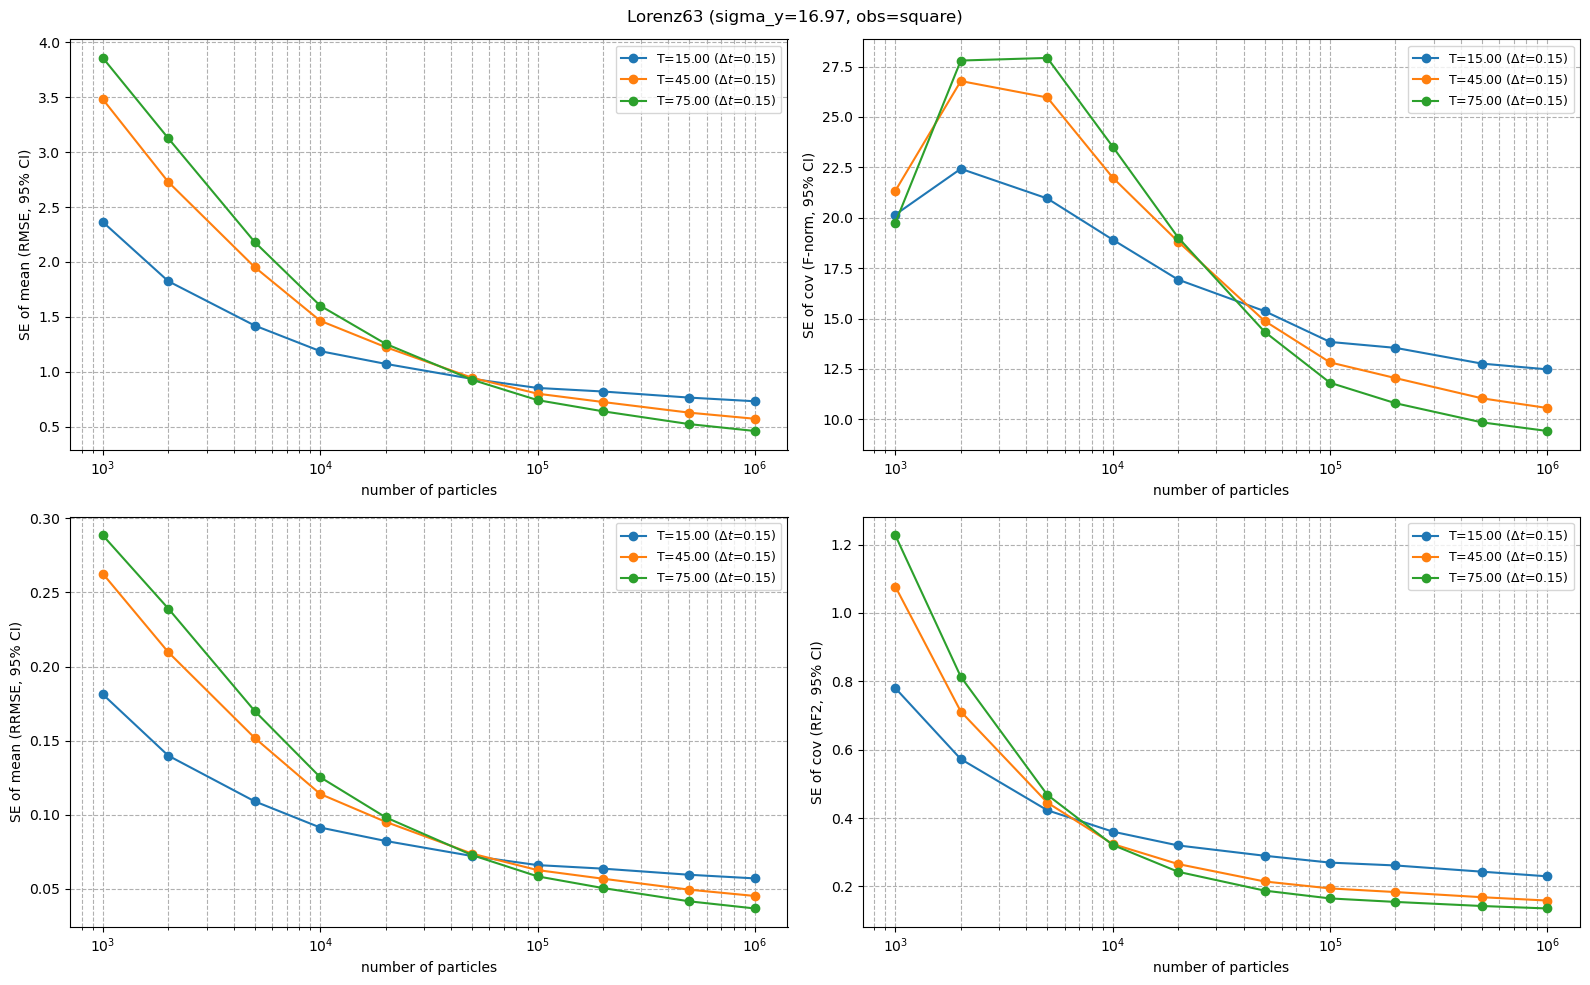

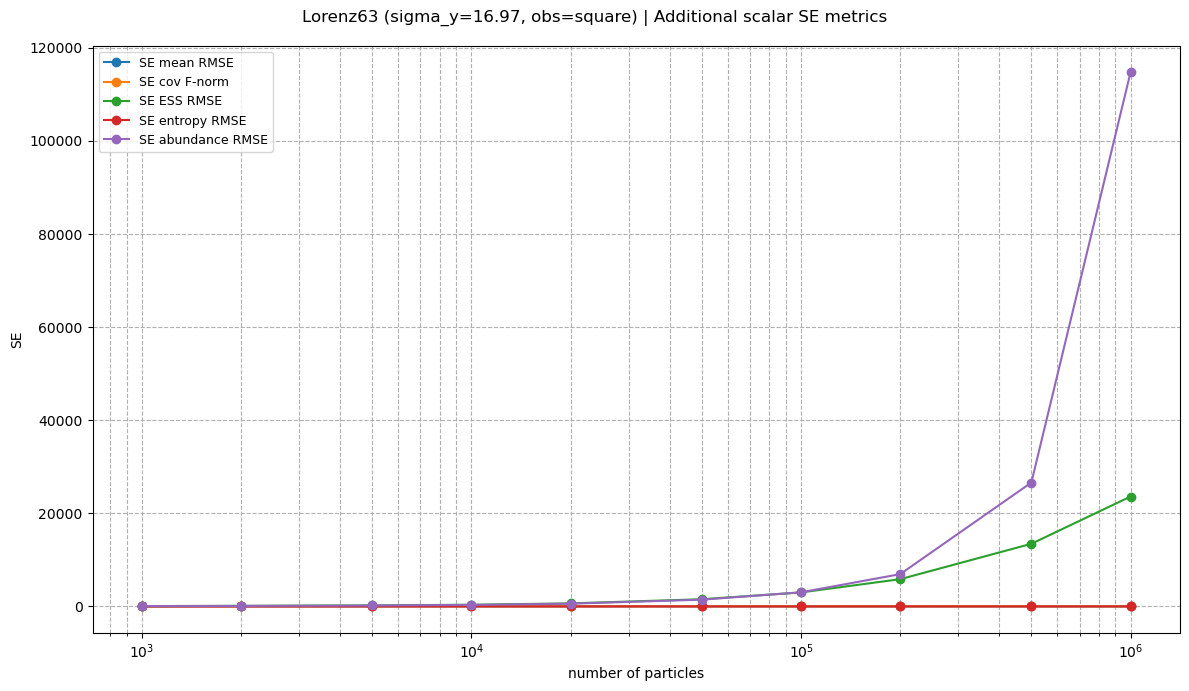

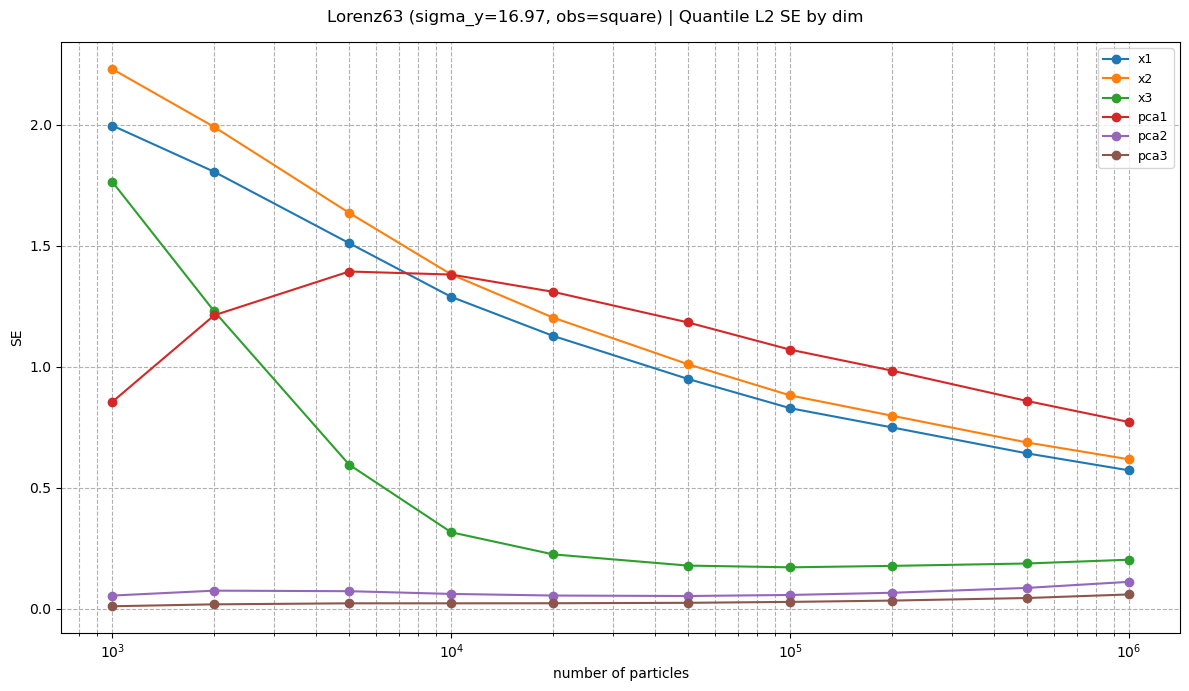

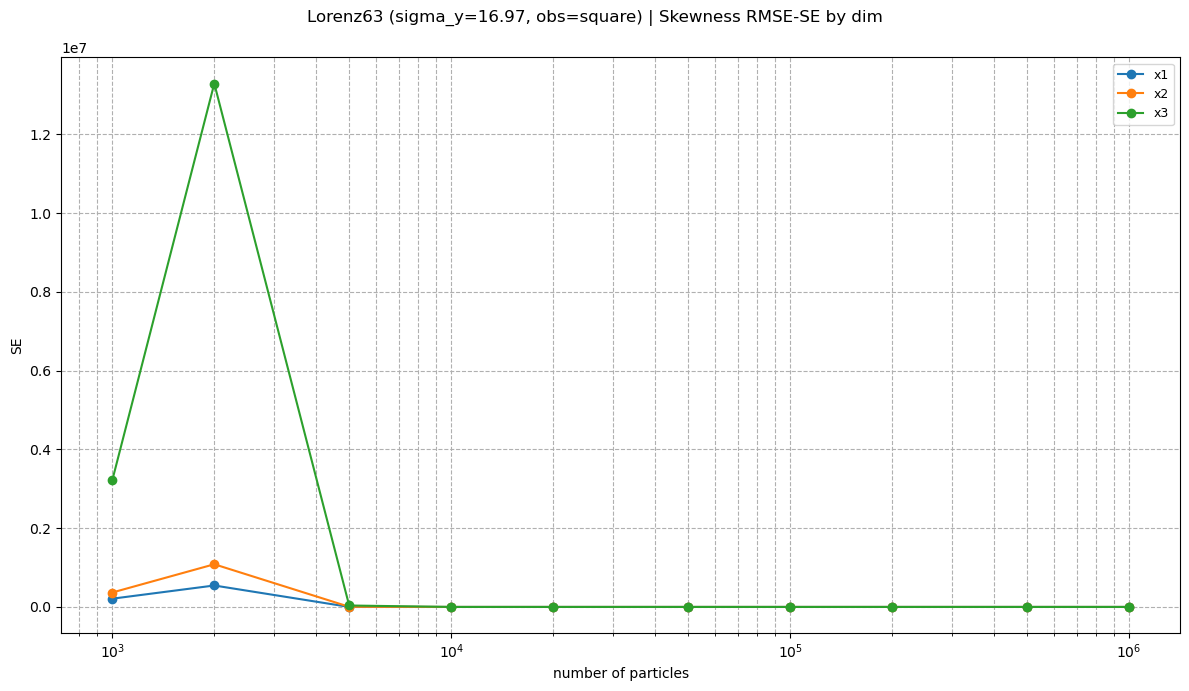

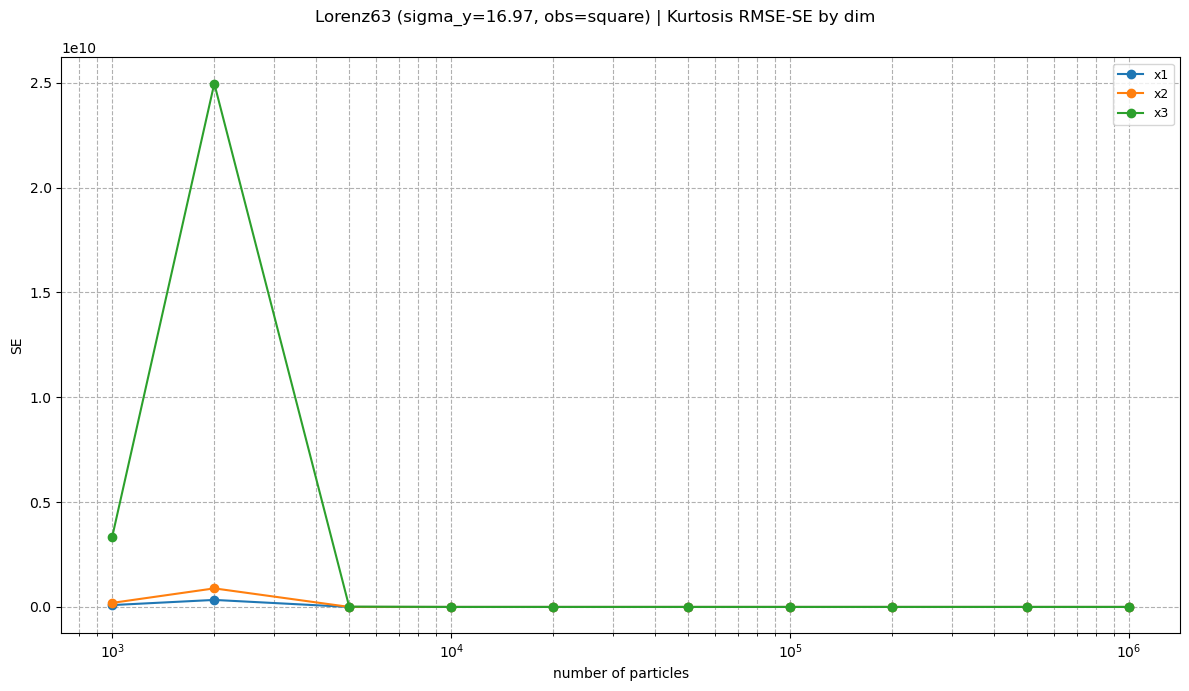


Done. Results stored in `results`.


In [16]:
SELECTED_EXPERIMENTS = [
    # "lorenz63_sigma_1.0",
    # "lorenz63_sigma_1.0_square",
    # "lorenz63_identity_sigma_2.0",
    "lorenz63_square_sigma_16.97",
    # "lorenz63_arctan_sigma_0.32",
    # "rossler_sigma_1.0",
    # "lorenz96_sigma_1.0",
    # "circle_sigma_1.0",
    # "hdoublewell_sigma_1.0",
    # "doubling1d_sigma_0.1",
    # "complex2d_sigma_0.1",
]

results = {}
for exp_key in SELECTED_EXPERIMENTS:
    cfg = EXPERIMENTS[exp_key]
    results[exp_key] = run_experiment(cfg)

print("\nDone. Results stored in `results`.")

